In [11]:
from sentence_transformers import SentenceTransformer
import tqdm as notebook_tqdm
import torch
from tqdm import tqdm
# Load the embedding model
model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")
print("Model loaded!")

Loading weights: 100%|██████████| 310/310 [00:00<00:00, 12051.82it/s]


Model loaded!


In [2]:
# Import required libraries for image downloading and display
import requests
from requests.auth import HTTPBasicAuth
from io import BytesIO
from PIL import Image as PILImage
from IPython.display import display
import os
from dotenv import load_dotenv
load_dotenv()

# Nextcloud configuration
NC_HOST = os.getenv("DB_HOST")
NC_ACC = os.getenv("NC_ACC")
NC_PASS = os.getenv("NC_PASS")

print(f"Nextcloud host: {NC_HOST}")
print(f"Nextcloud account: {NC_ACC}")

Nextcloud host: 192.168.0.150
Nextcloud account: Tom


In [3]:
def get_images(file_id, file_path):
    """
    Download and display a thumbnail/preview for a file from Nextcloud.
    
    Args:
        file_id: The Nextcloud file ID
        file_path: The path to the file on the Nextcloud server
    
    Returns:
        PIL.Image: The resized 256x256 PIL Image
    """
    server_url = f'http://{NC_HOST}:8080/remote.php/dav/files/{NC_ACC}'
    preview_url = f'http://{NC_HOST}:8080/core/preview?fileId={file_id}&x=1080&y=1080'
    username = NC_ACC
    password = NC_PASS

    file_url = f"{server_url}{file_path}"

    response = requests.get(preview_url, auth=HTTPBasicAuth(username, password), stream=True)
 
    if response.status_code == 200:
        file_in_memory = BytesIO()
        for chunk in response.iter_content(chunk_size=1024):
            if chunk:
                file_in_memory.write(chunk)
        file_in_memory.seek(0)
        img = PILImage.open(file_in_memory)
        img = img.resize((256, 256))
        display(img)
    elif response.status_code == 404:
        try:
            response = requests.get(file_url, auth=HTTPBasicAuth(username, password), stream=True)
            file_in_memory = BytesIO()
            for chunk in response.iter_content(chunk_size=1024):
                if chunk:
                    file_in_memory.write(chunk)
            file_in_memory.seek(0)
            source_img = PILImage.open(file_in_memory)
            img_display = source_img.resize((256, 256))
            display(img_display)
        except Exception as e:
            print(f"Failed to download file. Exception: {e}")
    else:
        print(f"Failed to download file. Status code: {response.status_code}")
    
    try:
        import gc
        del file_in_memory
        gc.collect()
    except:
        pass
    return img

In [4]:
from sqlalchemy import create_engine, MetaData, Table, select, insert
from sqlalchemy.exc import SQLAlchemyError
import pandas as pd

def create_db_connection():
    load_dotenv()
    DB_HOST = os.getenv("DB_HOST")
    DB_NAME = os.getenv("DB_NAME")
    DB_USER = os.getenv("DB_USER")
    DB_PASSWORD = os.getenv("DB_PASSWORD")
    engine = create_engine('postgresql+pg8000://'+DB_USER+':'+DB_PASSWORD+'@'+DB_HOST+':5432/'+DB_NAME)
    return engine

def get_tags():
    try:
        engine = create_db_connection()
        df_systag = pd.read_sql_table('oc_systemtag', engine)
        df_tagmap = pd.read_sql_table('oc_systemtag_object_mapping', engine)
    except SQLAlchemyError as e:
        print(f"An error occurred: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
    return df_systag, df_tagmap

In [5]:
print("Loading tags from database...")
df_systag, df_tagmap = get_tags()
print(f"Loaded {len(df_systag)} tags and {len(df_tagmap)} mappings")

Loading tags from database...
Loaded 766 tags and 21533 mappings


In [6]:
# ============================================
# Document Aggregation Approach
# ============================================
# Build a document for each file by aggregating all its tags.
# This creates a richer semantic representation per file.

def build_file_documents(df_systag, df_tagmap):
    """
    Build a dictionary mapping file IDs to their aggregated tag documents.
    
    Args:
        df_systag: DataFrame with tag id and name columns
        df_tagmap: DataFrame with systemtagid and objectid columns
    
    Returns:
        dict: {file_id: "tag1 tag2 tag3 ..."}
    """
    # Merge tagmap with tag names
    tagmap_with_names = df_tagmap.merge(
        df_systag[['id', 'name']],
        left_on='systemtagid',
        right_on='id',
        how='inner'
    )
    
    # Group by file_id (objectid) and aggregate tag names
    file_docs = {}
    for file_id, group in tagmap_with_names.groupby('objectid'):
        # Sort tags alphabetically for consistency, deduplicate
        tags = sorted(set(group['name'].tolist()))
        file_docs[str(file_id)] = ' '.join(tags)
    
    return file_docs, tagmap_with_names

file_documents, tagmap_with_names = build_file_documents(df_systag, df_tagmap)
print(f"Built {len(file_documents)} file documents")

# Show some examples
print("\nExample file documents:")
for i, (file_id, doc) in enumerate(list(file_documents.items())[:5]):
    print(f"  File {file_id}: '{doc}'")

Built 1517 file documents

Example file documents:
  File 1000: 'abstract design element eye graphic icon iconography illustration minimalist modern orange red simplistic symbol visual'
  File 10001: 'botanical design digital floral graphic green greenish illustration inspire leaflike leave nature plant tropical'
  File 10017: 'abstract circle colorful composition contemporary form geometric minimalist modern semi shape'
  File 1003: 'background design evil eye folk graphic icon minimalist modern mystery mystic symbol symbolism yellow'
  File 10035: 'abstract artistic blue botanical composition digital floral geometric green inspire minimalist modern nature pattern teal textured'


In [7]:
# ============================================
# Pre-compute Document Embeddings
# ============================================
# Encode all file documents once, then use for similarity search

print("Encoding all file documents...")
doc_ids = list(file_documents.keys())
doc_texts = list(file_documents.values())

# Encode all documents at once for efficiency
doc_embeddings = model.encode(doc_texts)
print(f"Encoded {len(doc_embeddings)} documents")
print(f"Embedding shape: {doc_embeddings.shape}")

Encoding all file documents...
Encoded 1517 documents
Embedding shape: (1517, 1024)


In [8]:
# ============================================
# Document Similarity Search Function
# ============================================

def search_files_by_document_similarity(query, top_k=10):
    """
    Search for files by comparing query against pre-computed file document embeddings.
    
    Args:
        query: Natural language search query
        top_k: Number of top results to return
    
    Returns:
        DataFrame with file_id, document, similarity score, ranked
    """
    # Encode the query
    query_embedding = model.encode(query, prompt_name="query")
    
    # Compute cosine similarity between query and all document embeddings
    similarity = model.similarity(
        torch.tensor(query_embedding).unsqueeze(0),
        torch.tensor(doc_embeddings)
    )
    
    # Get top-k indices
    top_indices = similarity[0].argsort(descending=True)[:top_k]
    
    # Build results DataFrame
    results = pd.DataFrame({
        'file_id': [doc_ids[i] for i in top_indices],
        'document': [doc_texts[i] for i in top_indices],
        'similarity': similarity[0][top_indices].cpu().numpy()
    })
    
    return results

print("Search function ready!")

Search function ready!


In [15]:
# ============================================
# Display Thumbnails for Search Results
# ============================================

def display_doc_search_thumbnails(results, top_n):
    """
    Display thumbnails for the top N files from document search results.
    
    Args:
        results: DataFrame with file_id column
        top_n: Number of thumbnails to display (default 3)
    """
    if results.empty:
        print("No files found.")
        return
    
    print(f"\nDisplaying top {min(top_n, len(results))} thumbnails:")
    for i, row in results.head(top_n).iterrows():
        file_id = row['file_id']
        print(f"Thumbnail {i+1}: File ID = {file_id}, Similarity = {row['similarity']:.4f}")
        file_path = "/images/"
        try:
            img = get_images(file_id, file_path)
        except Exception as e:
            print(f"  Failed to load image: {e}")
        print()

  0%|          | 0/3 [00:00<?, ?it/s]


Query: 'A painting with green landscape scene'

Top 10 results:
file_id                                                                                                                                          document  similarity
   5381                      abstract artistic botanical flower foliage green impressionist landscape leave modern nature orange painting tropical yellow    0.612780
   5331        abstract artistic blurred calm contemporary green impressionism landscape minimalist modern nature organic painting smooth soft watercolor    0.596860
   5712                        abstract colorful composition contemporary expressionism green impressionist landscape modern nature painting pink red sky    0.589444
   5157                                             abstract colorful composition expressionism green impressionist landscape modern orange painting pink    0.578154
  10458         abstract blue colorful composition flower foliage green impressionism impressionist lands

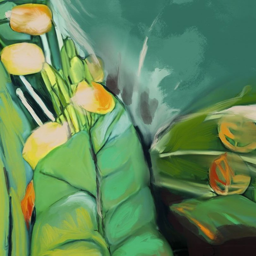


Thumbnail 2: File ID = 5331, Similarity = 0.5969


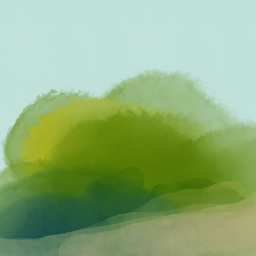


Thumbnail 3: File ID = 5712, Similarity = 0.5894


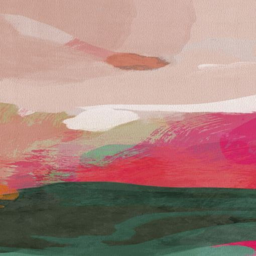

 33%|███▎      | 1/3 [00:02<00:04,  2.23s/it]



Query: 'portrait of a person'

Top 10 results:
file_id                                                                                                                    document  similarity
   4027      abstract black contemporary dramatic emotional expressive figure floral nature pink portrait red soft surrealism white    0.440143
   5171 abstract artwork colorful contemporary figure flower green hat impressionism orange painting pink portrait red woman yellow    0.408965
    656     abstract artwork colorful contemporary design figure geometric human minimalist modern pink purple red shape silhouette    0.379917
   5405                                                             abstract colorful composition expressive figure modern painting    0.362478
    723                   abstract artwork colorful composition contemporary expressionism figure modern painting piece visual work    0.337788
    794                                                    abstract blue composition co

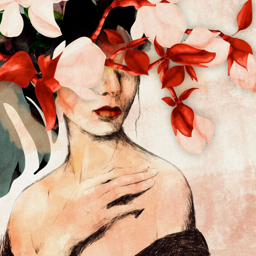


Thumbnail 2: File ID = 5171, Similarity = 0.4090


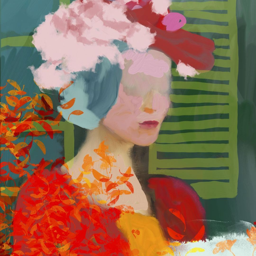


Thumbnail 3: File ID = 656, Similarity = 0.3799


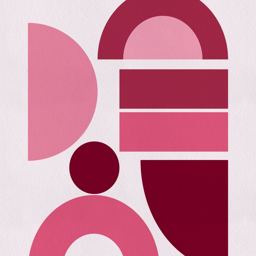

 67%|██████▋   | 2/3 [00:04<00:02,  2.14s/it]



Query: 'abstract art with bright colors'

Top 10 results:
file_id                                                                                                                   document  similarity
   5679                      abstract bright colorful composition contemporary expressionism impressionism modern painting vibrant    0.667617
   7153             abstract artwork colorful composition contemporary design digital geometric minimalist modern painting vibrant    0.651061
   5382          abstract artwork colorful composition contemporary expressionism expressive impressionist modern painting vibrant    0.636157
   8419                         abstract artistic colorful composition contemporary design geometric modern painting shape vibrant    0.623913
    684                         abstract artistic colorful composition contemporary design geometric modern painting shape vibrant    0.623913
   5419 abstract artwork blot bright colorful contemporary expressionist minimalis

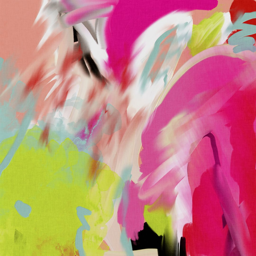


Thumbnail 2: File ID = 7153, Similarity = 0.6511


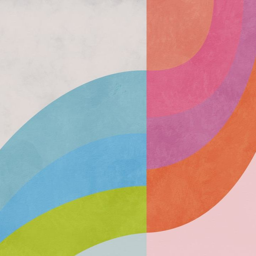


Thumbnail 3: File ID = 5382, Similarity = 0.6362


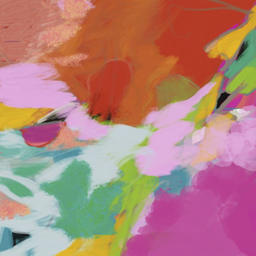

100%|██████████| 3/3 [00:06<00:00,  2.14s/it]

In [12]:
# ============================================
# Run Document-Based Search Tests
# ============================================

test_queries = [
    "A painting with green landscape scene",
    "portrait of a person",
    "abstract art with bright colors",
]

for query in tqdm(test_queries):
    print(f"\n{'='*60}")
    print(f"Query: '{query}'")
    print(f"{'='*60}")
    
    # Search using document similarity
    results = search_files_by_document_similarity(query, top_k=10)
    
    print(f"\nTop 10 results:")
    print(results.to_string(index=False))
    
    # Display top 3 thumbnails
    display_doc_search_thumbnails(results, top_n=3)

  0%|          | 0/3 [00:00<?, ?it/s]


Query: 'coloful contemproary art for a wallpaper'

Top 10 results:
file_id                                                                                                                                 document  similarity
   9804                       abstract artwork circle colorful cool decor design earthy geometric modern pattern textured vibrant wallpaper warm    0.595962
   7091                       abstract artistic circle colorful composition decor design geometric home interior modern pastel pattern wallpaper    0.575023
   7043            abstract artistic circle colorful composition decor decorative design geometric home modern pattern textile vibrant wallpaper    0.564007
   9122                     abstract artistic circle colorful composition decor design geometric modern mosaic pattern texture vibrant wallpaper    0.560544
   7760 abstract artistic circle colorful composition decor decorative design geometric home minimalist modern pattern textile vibrant wallpaper   

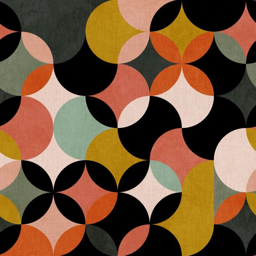


Thumbnail 2: File ID = 7091, Similarity = 0.5750


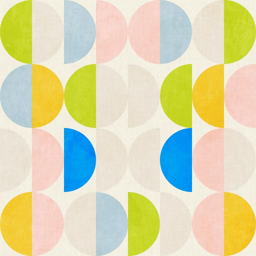


Thumbnail 3: File ID = 7043, Similarity = 0.5640


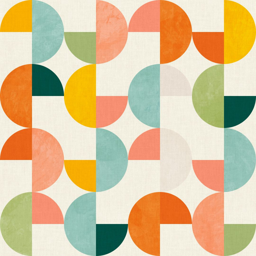


Thumbnail 4: File ID = 9122, Similarity = 0.5605


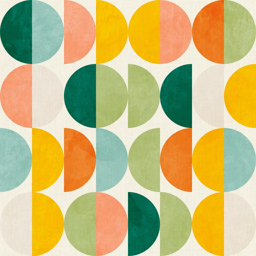


Thumbnail 5: File ID = 7760, Similarity = 0.5576


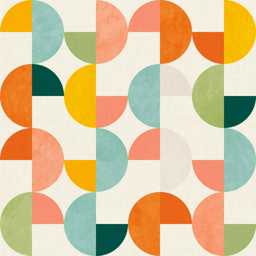

 33%|███▎      | 1/3 [00:03<00:06,  3.43s/it]



Query: 'greek villages'

Top 10 results:
file_id                                                                                                                                           document  similarity
   3844 architecture blue building cloud coastal greece house landscape mediterranean mountain nature painting residential scenic seaside sky street white    0.388742
    934            architecture building cityscape colorful community composition drawing house housing illustration minimalist pastel rural urban village    0.341122
   8827                                           architecture blue brown building community composition green home house illustration pattern red village    0.318340
   2576                              abstract architecture bridge colorful composition fantasy folk gray green house nature roof surrealism village window    0.299809
   7346            architecture beige building cityscape composition drawing home house illustration minimalist silhouette

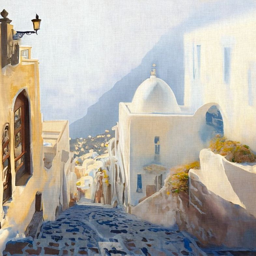


Thumbnail 2: File ID = 934, Similarity = 0.3411


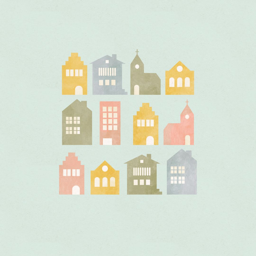


Thumbnail 3: File ID = 8827, Similarity = 0.3183


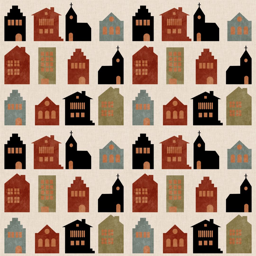


Thumbnail 4: File ID = 2576, Similarity = 0.2998
Failed to download file. Exception: cannot identify image file <_io.BytesIO object at 0x73abc1fac090>
  Failed to load image: cannot access local variable 'img' where it is not associated with a value

Thumbnail 5: File ID = 7346, Similarity = 0.2882


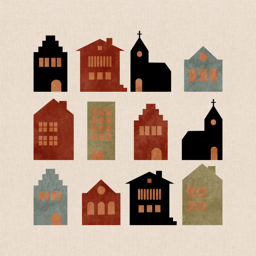

 67%|██████▋   | 2/3 [00:07<00:03,  3.71s/it]



Query: 'primarily green wallpaper patterns which are repetitive with flowers'

Top 10 results:
file_id                                                                                                                          document  similarity
   1196            botanical decorative floral flower green nature orange pattern peach repetition retro simplicity symmetry teal vintage    0.679955
  12421              abstract artistic botanical decor design floral green home inspire interior nature organic pattern texture wallpaper    0.669959
    647        background colorful decorative design geometric green home modern neutral pattern pink repetitive texture wallpaper yellow    0.663234
   1199                                blue botanical design floral flower geometric green leaf nature pattern petal pink repeat symmetry    0.659263
   7255 abstract botanical brown composition design geometric green leave minimalist nature neutral pattern repeat texture tone wallpaper    0.658280
   

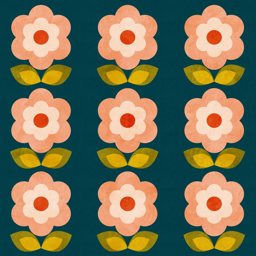


Thumbnail 2: File ID = 12421, Similarity = 0.6700


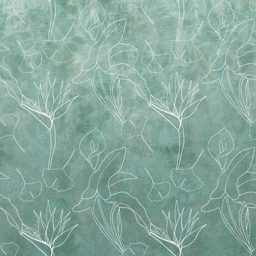


Thumbnail 3: File ID = 647, Similarity = 0.6632


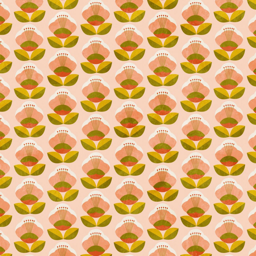


Thumbnail 4: File ID = 1199, Similarity = 0.6593


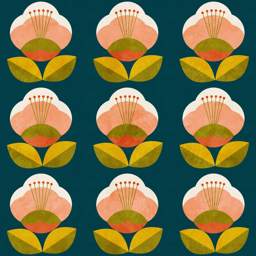


Thumbnail 5: File ID = 7255, Similarity = 0.6583


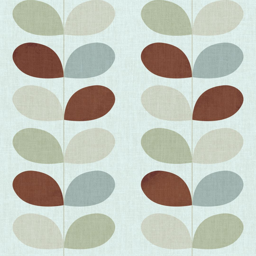

100%|██████████| 3/3 [00:10<00:00,  3.57s/it]

In [18]:
# ============================================
# Run Document-Based Search Tests
# ============================================

test_queries = [
    "coloful contemproary art for a wallpaper",
    "greek villages",
    "primarily green wallpaper patterns which are repetitive with flowers",
]

for query in tqdm(test_queries):
    print(f"\n{'='*60}")
    print(f"Query: '{query}'")
    print(f"{'='*60}")
    
    # Search using document similarity
    results = search_files_by_document_similarity(query, top_k=10)
    
    print(f"\nTop 10 results:")
    print(results.to_string(index=False))
    
    # Display top 3 thumbnails
    display_doc_search_thumbnails(results, top_n=5)

  0%|          | 0/1 [00:00<?, ?it/s]


Query: 'show me lemmons!'

Top 10 results:
file_id                                                                                                                            document  similarity
    732                   abstract black citrus food fruit geometric lemons life minimalist modern nature orange pattern still white yellow    0.341954
   3653                    bloom blossom branch delicate floral fruit green lemons life nature spring still vibrant watercolor white yellow    0.326507
   8036            avocado bright citrus colorful delightful design fruit illustration lemons nature orange organic papaya pattern tropical    0.323903
   1178                  abstract citrus foliage food fruit geometric green lemons life minimalist nature orange shape still texture yellow    0.323413
    761       abstract black citrus design floral fruit geometric illustration lemons life nature orange pattern still textile white yellow    0.305670
    985                 abstract citrus comp

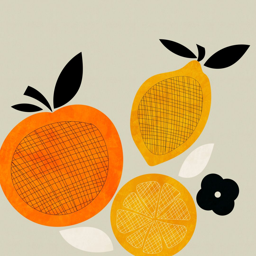


Thumbnail 2: File ID = 3653, Similarity = 0.3265


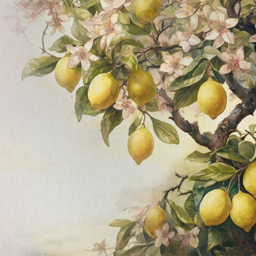


Thumbnail 3: File ID = 8036, Similarity = 0.3239


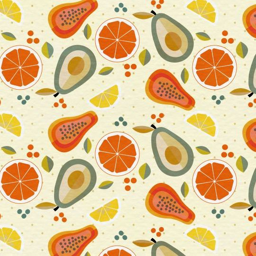


Thumbnail 4: File ID = 1178, Similarity = 0.3234


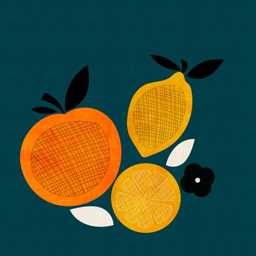


Thumbnail 5: File ID = 761, Similarity = 0.3057


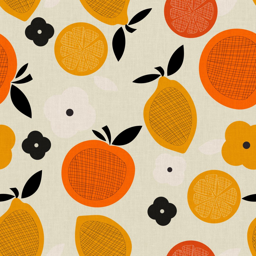

100%|██████████| 1/1 [00:03<00:00,  3.37s/it]

In [19]:
# ============================================
# Run Document-Based Search Tests
# ============================================

test_queries = [
    "show me lemmons!",
]


for query in tqdm(test_queries):
    print(f"\n{'='*60}")
    print(f"Query: '{query}'")
    print(f"{'='*60}")
    
    # Search using document similarity
    results = search_files_by_document_similarity(query, top_k=10)
    
    print(f"\nTop 10 results:")
    print(results.to_string(index=False))
    
    # Display top 3 thumbnails
    display_doc_search_thumbnails(results, top_n=5)